In [1]:
import os
import pandas as pd
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from itertools import product
from scipy import stats
import seaborn as sns

os.chdir("/Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-network-analysis")

print("Working directory:", os.getcwd())

Working directory: /Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-network-analysis


In [2]:
# Load and filter data
ged = pd.read_csv("data/GEDEvent_v25_1.csv", low_memory=False)
ged['date_start'] = pd.to_datetime(ged['date_start'])

ethiopia = ged[
    (ged['country'] == 'Ethiopia') &
    (ged['date_start'] >= '2020-11-01') &
    (ged['date_start'] <= '2022-11-30')
].copy()

# Actor splitting function
def split_actors(actor_string):
    if pd.isna(actor_string):
        return []
    parts = [a.strip() for a in actor_string.split(',')]
    merged = []
    i = 0
    while i < len(parts):
        if parts[i].startswith('Government of'):
            merged.append(parts[i])
        elif i + 1 < len(parts) and parts[i + 1].startswith('Government of'):
            merged.append(parts[i])
        elif i == len(parts) - 1:
            merged.append(parts[i])
        else:
            merged.append(parts[i])
        i += 1
    return merged

# Build rivalry network (excluding civilian events)
battle_events = ethiopia[ethiopia['side_b'] != 'Civilians'].copy()

edges = []
for _, row in battle_events.iterrows():
    actors_a = split_actors(row['side_a'])
    actors_b = split_actors(row['side_b'])
    for a, b in product(actors_a, actors_b):
        actor_pair = tuple(sorted([a, b]))
        edges.append({'actor_1': actor_pair[0], 'actor_2': actor_pair[1]})

edge_df = pd.DataFrame(edges)
edge_weights = edge_df.groupby(['actor_1', 'actor_2']).size().reset_index(name='weight')

G = nx.Graph()
for _, row in edge_weights.iterrows():
    G.add_edge(row['actor_1'], row['actor_2'], weight=row['weight'])

# Compute centrality
strength = dict(G.degree(weight='weight'))
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G)

centrality_df = pd.DataFrame({
    'actor': list(G.nodes()),
    'degree': [G.degree(n) for n in G.nodes()],
    'strength': [strength[n] for n in G.nodes()],
    'degree_centrality': [degree_cent[n] for n in G.nodes()],
    'betweenness_centrality': [betweenness_cent[n] for n in G.nodes()]
})

print(f"Full dataset: {len(ethiopia)} events")
print(f"Battle events: {len(battle_events)}")
print(f"Network: {G.number_of_nodes()} actors, {G.number_of_edges()} edges")
print(f"\nCentrality table:")
print(centrality_df.sort_values('strength', ascending=False).to_string(index=False))

Full dataset: 1764 events
Battle events: 1210
Network: 15 actors, 11 edges

Centrality table:
                 actor  degree  strength  degree_centrality  betweenness_centrality
Government of Ethiopia       3      1197           0.214286                0.032967
                  TPLF       1       699           0.071429                0.000000
                   OLA       1       495           0.071429                0.000000
                 Gumuz       4         7           0.285714                0.054945
            Al-Shabaab       1         6           0.071429                0.000000
 Government of Somalia       1         6           0.071429                0.000000
                Amhara       2         5           0.142857                0.000000
                 Oromo       2         3           0.142857                0.000000
                   GLF       1         3           0.071429                0.000000
              Shinasha       1         2           0.071429       

In [3]:
# Extract one-sided violence events (type_of_violence == 3)
osv_events = ethiopia[ethiopia['type_of_violence'] == 3].copy()

print(f"One-sided violence events: {len(osv_events)}")
print(f"\nPerpetrators (side_a):")
print(osv_events['side_a'].value_counts())

# Compute actor-level civilian violence statistics
# side_a is the perpetrator in one-sided violence events
osv_stats = []

for actor_string, group in osv_events.groupby('side_a'):
    actors = split_actors(actor_string)
    for actor in actors:
        osv_stats.append({
            'actor': actor,
            'osv_events': len(group),
            'civilian_fatalities': group['deaths_civilians'].sum(),
            'total_fatalities': group['best'].sum()
        })

osv_df = pd.DataFrame(osv_stats)

# Aggregate in case an actor appears in multiple coalition entries
osv_df = osv_df.groupby('actor').agg(
    osv_events=('osv_events', 'sum'),
    civilian_fatalities=('civilian_fatalities', 'sum'),
    total_fatalities=('total_fatalities', 'sum')
).reset_index()

print(f"\nActor-level civilian violence:")
print(osv_df.sort_values('osv_events', ascending=False).to_string(index=False))

One-sided violence events: 554

Perpetrators (side_a):
side_a
Government of Ethiopia                           208
Government of Eritrea                            158
Government of Eritrea, Government of Ethiopia     62
TPLF                                              54
OLA                                               45
Fano                                              25
OLA - Fekade Abdisa faction                        2
Name: count, dtype: int64

Actor-level civilian violence:
                      actor  osv_events  civilian_fatalities  total_fatalities
     Government of Ethiopia         270                 3965              3965
      Government of Eritrea         220                 5995              5995
                       TPLF          54                  881               881
                        OLA          45                  205               205
                       Fano          25                  235               235
OLA - Fekade Abdisa faction        

In [4]:
# Merge centrality with one-sided violence stats
merged = osv_df.merge(centrality_df, on='actor', how='left')

# Fill NaN for actors not in the rivalry network
merged['degree'] = merged['degree'].fillna(0).astype(int)
merged['strength'] = merged['strength'].fillna(0).astype(int)
merged['degree_centrality'] = merged['degree_centrality'].fillna(0)
merged['betweenness_centrality'] = merged['betweenness_centrality'].fillna(0)
merged['in_rivalry_network'] = merged['actor'].isin(G.nodes())

print("Merged actor-level data:\n")
print(merged.sort_values('osv_events', ascending=False).to_string(index=False))

Merged actor-level data:

                      actor  osv_events  civilian_fatalities  total_fatalities  degree  strength  degree_centrality  betweenness_centrality  in_rivalry_network
     Government of Ethiopia         270                 3965              3965       3      1197           0.214286                0.032967                True
      Government of Eritrea         220                 5995              5995       0         0           0.000000                0.000000               False
                       TPLF          54                  881               881       1       699           0.071429                0.000000                True
                        OLA          45                  205               205       1       495           0.071429                0.000000                True
                       Fano          25                  235               235       0         0           0.000000                0.000000               False
OLA - Fekade A

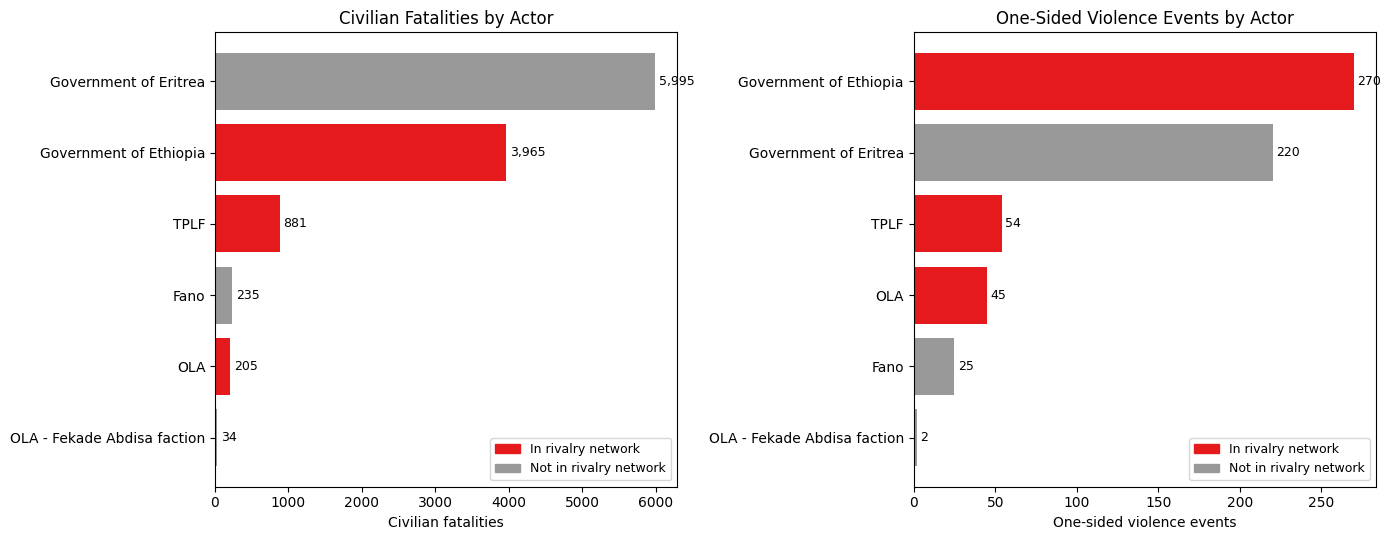

Saved to outputs/03_civilian_violence_by_actor.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Sort by civilian fatalities
merged_sorted = merged.sort_values('civilian_fatalities', ascending=True)

# Color by network membership
colors = ['#e41a1c' if x else '#999999' for x in merged_sorted['in_rivalry_network']]

# Plot 1: Civilian fatalities by actor
ax1 = axes[0]
bars1 = ax1.barh(merged_sorted['actor'], merged_sorted['civilian_fatalities'], color=colors)
ax1.set_xlabel('Civilian fatalities')
ax1.set_title('Civilian Fatalities by Actor')

# Add value labels
for bar, val in zip(bars1, merged_sorted['civilian_fatalities']):
    ax1.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

legend_patches = [
    mpatches.Patch(color='#e41a1c', label='In rivalry network'),
    mpatches.Patch(color='#999999', label='Not in rivalry network')
]
ax1.legend(handles=legend_patches, loc='lower right', fontsize=9)

# Plot 2: OSV events by actor
ax2 = axes[1]
merged_sorted2 = merged.sort_values('osv_events', ascending=True)
colors2 = ['#e41a1c' if x else '#999999' for x in merged_sorted2['in_rivalry_network']]
bars2 = ax2.barh(merged_sorted2['actor'], merged_sorted2['osv_events'], color=colors2)
ax2.set_xlabel('One-sided violence events')
ax2.set_title('One-Sided Violence Events by Actor')

for bar, val in zip(bars2, merged_sorted2['osv_events']):
    ax2.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)

ax2.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/03_civilian_violence_by_actor.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to outputs/03_civilian_violence_by_actor.png")

In [6]:
# Descriptive comparison: actors in vs. not in the rivalry network
in_network = merged[merged['in_rivalry_network'] == True]
out_network = merged[merged['in_rivalry_network'] == False]

print("DESCRIPTIVE COMPARISON: Network Position and Civilian Violence\n")
print(f"{'Metric':<30} {'In network (n=3)':>18} {'Not in network (n=3)':>22}")
print("-" * 72)
print(f"{'Total OSV events':<30} {in_network['osv_events'].sum():>18} {out_network['osv_events'].sum():>22}")
print(f"{'Mean OSV events':<30} {in_network['osv_events'].mean():>18.1f} {out_network['osv_events'].mean():>22.1f}")
print(f"{'Total civilian fatalities':<30} {in_network['civilian_fatalities'].sum():>18,} {out_network['civilian_fatalities'].sum():>22,}")
print(f"{'Mean civilian fatalities':<30} {in_network['civilian_fatalities'].mean():>18,.1f} {out_network['civilian_fatalities'].mean():>18,.1f}")

print(f"""

KEY OBSERVATION:
  Actors present in the rivalry network committed {in_network['osv_events'].sum()} OSV events
  with {in_network['civilian_fatalities'].sum():,} civilian fatalities.

  Actors absent from the rivalry network committed {out_network['osv_events'].sum()} OSV events
  with {out_network['civilian_fatalities'].sum():,} civilian fatalities.

  Government of Eritrea alone accounts for {5995} civilian fatalities
  despite having no recorded battlefield interactions as a standalone actor
  in UCDP. This suggests UCDP coding conventions undercount Eritrean
  military engagement by folding it into coalition entries.
""")

DESCRIPTIVE COMPARISON: Network Position and Civilian Violence

Metric                           In network (n=3)   Not in network (n=3)
------------------------------------------------------------------------
Total OSV events                              369                    247
Mean OSV events                             123.0                   82.3
Total civilian fatalities                   5,051                  6,264
Mean civilian fatalities                  1,683.7            2,088.0


KEY OBSERVATION:
  Actors present in the rivalry network committed 369 OSV events
  with 5,051 civilian fatalities.

  Actors absent from the rivalry network committed 247 OSV events
  with 6,264 civilian fatalities.

  Government of Eritrea alone accounts for 5995 civilian fatalities
  despite having no recorded battlefield interactions as a standalone actor
  in UCDP. This suggests UCDP coding conventions undercount Eritrean
  military engagement by folding it into coalition entries.



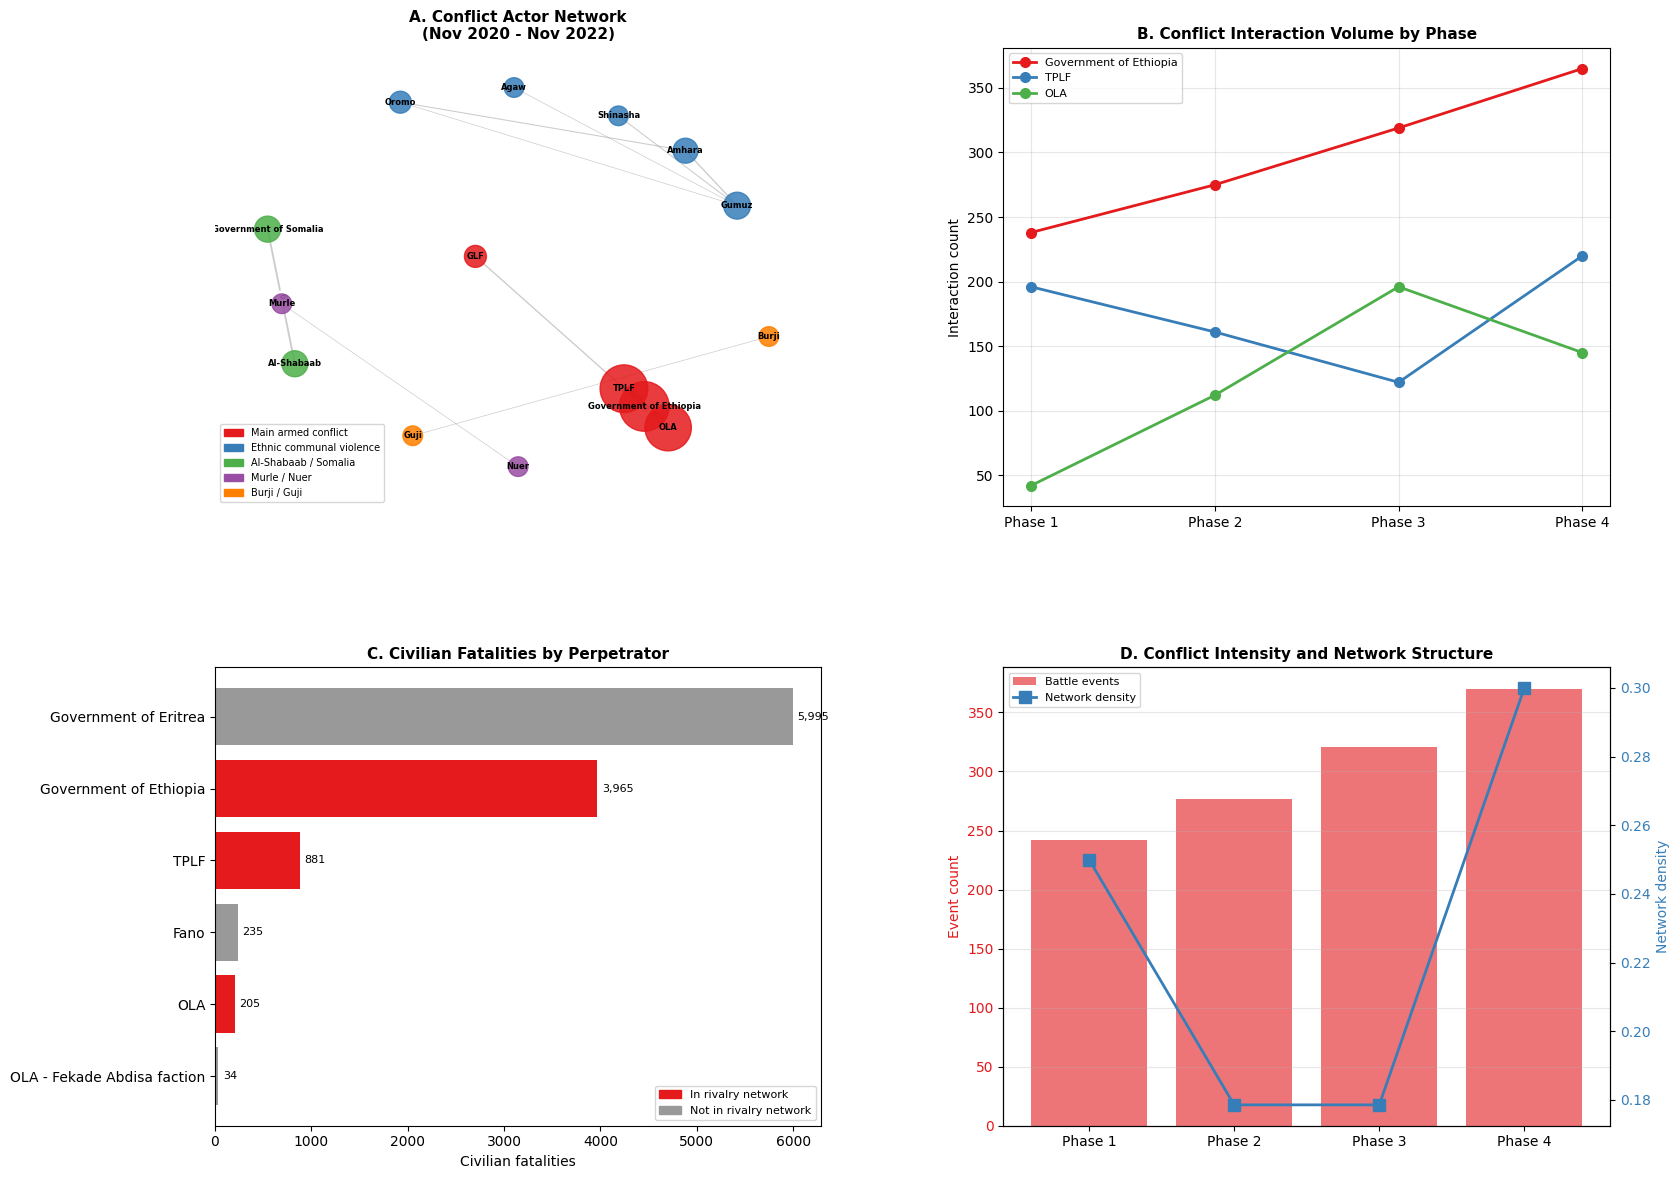

Saved to outputs/03_publication_figure.png


In [7]:
fig = plt.figure(figsize=(18, 14))

# Layout: 2 rows, top row has network + centrality table, bottom row has trajectories + civilian violence
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# --- Panel A: Static network (rebuilt here for clean layout) ---
ax_net = fig.add_subplot(gs[0, 0])

partition = community_louvain.best_partition(G)
community_colors = {0: '#e41a1c', 1: '#377eb8', 2: '#4daf4a', 3: '#984ea3', 4: '#ff7f00'}
node_colors = [community_colors[partition[n]] for n in G.nodes()]

strengths = [strength[n] for n in G.nodes()]
node_sizes = [max(200, np.log1p(s) * 180) for s in strengths]

edge_weights_list = [G[u][v]['weight'] for u, v in G.edges()]
edge_widths = [max(0.5, np.log1p(w) * 0.7) for w in edge_weights_list]

pos = nx.spring_layout(G, k=2.5, seed=42)

nx.draw_networkx_edges(G, pos, ax=ax_net, width=edge_widths, alpha=0.4, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax_net, node_size=node_sizes, node_color=node_colors, alpha=0.85)
nx.draw_networkx_labels(G, pos, ax=ax_net, font_size=6, font_weight='bold')

major_edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] > 5]
edge_labels = {(u, v): G[u][v]['weight'] for u, v in major_edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax_net, font_size=6)

legend_patches = [
    mpatches.Patch(color='#e41a1c', label='Main armed conflict'),
    mpatches.Patch(color='#377eb8', label='Ethnic communal violence'),
    mpatches.Patch(color='#4daf4a', label='Al-Shabaab / Somalia'),
    mpatches.Patch(color='#984ea3', label='Murle / Nuer'),
    mpatches.Patch(color='#ff7f00', label='Burji / Guji')
]
ax_net.legend(handles=legend_patches, loc='lower left', fontsize=7)
ax_net.set_title('A. Conflict Actor Network\n(Nov 2020 - Nov 2022)', fontsize=11, fontweight='bold')
ax_net.axis('off')

# --- Panel B: Actor trajectories (interaction volume) ---
ax_traj = fig.add_subplot(gs[0, 1])

key_actors = ['Government of Ethiopia', 'TPLF', 'OLA']
actor_colors_line = {
    'Government of Ethiopia': '#e41a1c',
    'TPLF': '#377eb8',
    'OLA': '#4daf4a'
}

phase_order = [
    'Phase 1: War Outbreak\n(Nov 2020 - Jun 2021)',
    'Phase 2: TPLF Counteroffensive\n(Jul 2021 - Dec 2021)',
    'Phase 3: Re-escalation\n(Jan 2022 - Jun 2022)',
    'Phase 4: Ceasefire & Peace\n(Jul 2022 - Nov 2022)'
]

# Rebuild phase networks for trajectory data
def assign_phase(date):
    if date <= pd.Timestamp('2021-06-30'):
        return phase_order[0]
    elif date <= pd.Timestamp('2021-12-31'):
        return phase_order[1]
    elif date <= pd.Timestamp('2022-06-30'):
        return phase_order[2]
    else:
        return phase_order[3]

battle_events_copy = ethiopia[ethiopia['side_b'] != 'Civilians'].copy()
battle_events_copy['phase'] = battle_events_copy['date_start'].apply(assign_phase)

phase_networks = {}
for phase in phase_order:
    phase_ev = battle_events_copy[battle_events_copy['phase'] == phase]
    p_edges = []
    for _, row in phase_ev.iterrows():
        actors_a = split_actors(row['side_a'])
        actors_b = split_actors(row['side_b'])
        for a, b in product(actors_a, actors_b):
            pair = tuple(sorted([a, b]))
            p_edges.append({'actor_1': pair[0], 'actor_2': pair[1]})
    p_df = pd.DataFrame(p_edges)
    p_weights = p_df.groupby(['actor_1', 'actor_2']).size().reset_index(name='weight')
    G_p = nx.Graph()
    for _, row in p_weights.iterrows():
        G_p.add_edge(row['actor_1'], row['actor_2'], weight=row['weight'])
    phase_networks[phase] = G_p

phase_labels = ['Phase 1', 'Phase 2', 'Phase 3', 'Phase 4']
for actor in key_actors:
    values = []
    for phase in phase_order:
        G_p = phase_networks[phase]
        if actor in G_p.nodes():
            s = dict(G_p.degree(weight='weight'))
            values.append(s[actor])
        else:
            values.append(0)
    ax_traj.plot(phase_labels, values, marker='o', linewidth=2, markersize=7,
                 color=actor_colors_line[actor], label=actor)

ax_traj.set_ylabel('Interaction count', fontsize=10)
ax_traj.legend(loc='upper left', fontsize=8)
ax_traj.grid(True, alpha=0.3)
ax_traj.set_title('B. Conflict Interaction Volume by Phase', fontsize=11, fontweight='bold')

# --- Panel C: Civilian fatalities by actor ---
ax_civ = fig.add_subplot(gs[1, 0])

merged_sorted = merged.sort_values('civilian_fatalities', ascending=True)
colors_bar = ['#e41a1c' if x else '#999999' for x in merged_sorted['in_rivalry_network']]

bars = ax_civ.barh(merged_sorted['actor'], merged_sorted['civilian_fatalities'], color=colors_bar)
for bar, val in zip(bars, merged_sorted['civilian_fatalities']):
    ax_civ.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8)

civ_legend = [
    mpatches.Patch(color='#e41a1c', label='In rivalry network'),
    mpatches.Patch(color='#999999', label='Not in rivalry network')
]
ax_civ.legend(handles=civ_legend, loc='lower right', fontsize=8)
ax_civ.set_xlabel('Civilian fatalities', fontsize=10)
ax_civ.set_title('C. Civilian Fatalities by Perpetrator', fontsize=11, fontweight='bold')

# --- Panel D: Network density and event count over time ---
ax_dual = fig.add_subplot(gs[1, 1])

densities = [nx.density(phase_networks[p]) for p in phase_order]
event_counts = [len(battle_events_copy[battle_events_copy['phase'] == p]) for p in phase_order]

color_dens = '#377eb8'
color_events = '#e41a1c'

ax_dual.bar(phase_labels, event_counts, color=color_events, alpha=0.6, label='Battle events')
ax_dual.set_ylabel('Event count', fontsize=10, color=color_events)
ax_dual.tick_params(axis='y', labelcolor=color_events)

ax_twin = ax_dual.twinx()
ax_twin.plot(phase_labels, densities, marker='s', linewidth=2, markersize=8,
             color=color_dens, label='Network density')
ax_twin.set_ylabel('Network density', fontsize=10, color=color_dens)
ax_twin.tick_params(axis='y', labelcolor=color_dens)

lines1, labels1 = ax_dual.get_legend_handles_labels()
lines2, labels2 = ax_twin.get_legend_handles_labels()
ax_dual.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
ax_dual.set_title('D. Conflict Intensity and Network Structure', fontsize=11, fontweight='bold')
ax_dual.grid(True, alpha=0.3, axis='y')

plt.savefig('outputs/03_publication_figure.png', dpi=250, bbox_inches='tight')
plt.show()
print("Saved to outputs/03_publication_figure.png")

In [8]:
print("=" * 65)
print("NOTEBOOK 03 SUMMARY: Network Metrics and Violence Outcomes")
print("=" * 65)

print(f"""
ONE-SIDED VIOLENCE AGAINST CIVILIANS
  Total events: 554
  Total civilian fatalities: 11,315
  Perpetrators identified: 6

PERPETRATORS IN THE RIVALRY NETWORK (n=3)
  Government of Ethiopia:  270 events, 3,965 fatalities
  TPLF:                     54 events,   881 fatalities
  OLA:                      45 events,   205 fatalities

PERPETRATORS NOT IN THE RIVALRY NETWORK (n=3)
  Government of Eritrea:   220 events, 5,995 fatalities
  Fano:                     25 events,   235 fatalities
  OLA - Fekade Abdisa:       2 events,    34 fatalities

KEY FINDINGS

  1. Government of Eritrea committed the most civilian fatalities
     (5,995) but does not appear as an independent combatant in
     the UCDP rivalry data. All its events are coded as civilian
     targeting or as part of a coalition with Government of
     Ethiopia. This is a data structure limitation worth noting
     in any analysis using UCDP for network construction.

  2. Among actors present in both datasets, Government of
     Ethiopia has both the highest network centrality and the
     highest civilian violence count. TPLF and OLA follow in
     both rankings. The pattern is consistent with the idea
     that structurally central actors commit more civilian
     violence, but with only 3 overlapping actors, no
     statistical test is appropriate.

  3. Actors absent from the rivalry network still committed
     more total civilian fatalities (6,264) than those present
     (5,051). This is driven entirely by Government of Eritrea,
     suggesting that some of the deadliest actors in a conflict
     operate through coalition warfare and civilian targeting
     rather than direct battlefield engagement.

  4. The temporal pattern shows conflict consolidation: fewer
     actors fighting more intensely over time, with peak
     violence in Phase 4 immediately before the November 2022
     ceasefire.

OUTPUTS
  outputs/03_civilian_violence_by_actor.png
  outputs/03_publication_figure.png
""")

NOTEBOOK 03 SUMMARY: Network Metrics and Violence Outcomes

ONE-SIDED VIOLENCE AGAINST CIVILIANS
  Total events: 554
  Total civilian fatalities: 11,315
  Perpetrators identified: 6

PERPETRATORS IN THE RIVALRY NETWORK (n=3)
  Government of Ethiopia:  270 events, 3,965 fatalities
  TPLF:                     54 events,   881 fatalities
  OLA:                      45 events,   205 fatalities

PERPETRATORS NOT IN THE RIVALRY NETWORK (n=3)
  Government of Eritrea:   220 events, 5,995 fatalities
  Fano:                     25 events,   235 fatalities
  OLA - Fekade Abdisa:       2 events,    34 fatalities

KEY FINDINGS

  1. Government of Eritrea committed the most civilian fatalities
     (5,995) but does not appear as an independent combatant in
     the UCDP rivalry data. All its events are coded as civilian
     targeting or as part of a coalition with Government of
     Ethiopia. This is a data structure limitation worth noting
     in any analysis using UCDP for network construction.
